In [92]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import warnings

## Avoid printing out warnings
with warnings.catch_warnings():
     warnings.filterwarnings("ignore")
     bc = load_breast_cancer()
     X, y = bc.data, bc.target

In [93]:
print(X.shape)
print(y.shape)

(569, 30)
(569,)


# Exploring the Dateaset

In [94]:
df = pd.DataFrame(data=X, columns=bc.feature_names)

print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# Logistic Regression using Gradient Descent

In [119]:
#diving data to test and train set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#add bias
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

In [149]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
    
def log_loss(y_true, y_pred):
    #avoid log(0) by adding a small epsilon value
    return -np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def compute_gradient(X, y, theta): 
    len = X.shape[0]
    y_pred = sigmoid(X @ theta)
    gradients = (1/len) * (X.T @ (y_pred-y))
    return gradients

In [161]:
threshold = 0.5
learning_rate = 0.5
iterations = 5000

def gradient_descent(X, y, learning_rate, iterations):
    weights = np.random.rand(X.shape[1])
    losses = []
    for i in range(iterations):
        gradients = compute_gradient(X, y, weights)
        weights -= learning_rate * gradients
        # print(weights)
        if i % 100 == 0 and i!=0:
            loss = log_loss(y, sigmoid(X @ weights))
            losses.append(loss)
            # print(i,loss)
    return weights, losses

weights, losses = gradient_descent(X_train, y_train, learning_rate, iterations)

print(f"Coefficient vector w: {weights}")

Coefficient vector w: [-3.12161806e-01 -2.16720901e-01  1.48997012e-01  2.81756679e-01
 -1.74923099e-01 -1.94760533e-03  2.36776467e+00 -1.77990970e+00
 -2.86927806e+00  9.88160835e-01 -6.65047219e-01 -3.14999606e+00
  6.17233612e-01 -8.99402676e-01 -2.75959188e+00 -8.40698929e-01
  7.02963354e-01  1.27550271e+00 -1.09978769e+00  1.18342162e+00
  1.63963202e+00 -1.82430045e+00 -2.94406621e+00 -1.30944996e-01
 -1.88861538e+00 -1.65834527e-01  8.62968892e-02 -2.16999074e+00
 -1.12889746e+00 -2.75315296e+00 -2.90394396e-01]


In [162]:
linear_model_test = X_test @ weights
y_pred_test = sigmoid(linear_model_test)
y_pred_binary = (y_pred_test>=threshold).astype(int)

precision = precision_score(y_test, y_pred_binary)
recall = recall_score(y_test, y_pred_binary)
f1 = f1_score(y_test, y_pred_binary)
conf_matrix = confusion_matrix(y_test, y_pred_binary)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"Confusion Matrix: {conf_matrix}")

Precision: 0.9857142857142858
Recall: 0.971830985915493
F1 Score: 0.9787234042553192
Confusion Matrix: [[42  1]
 [ 2 69]]


# Log Loss Plot

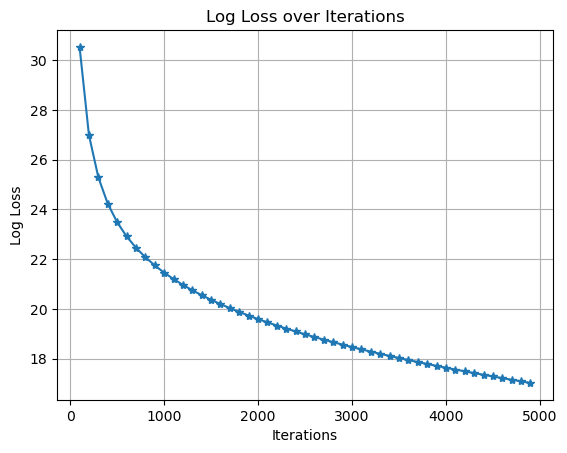

In [157]:
plt.plot(range(100, iterations, 100), losses, marker='*')
plt.title('Log Loss over Iterations')
plt.xlabel('Iterations')
plt.ylabel('Log Loss')
plt.grid(True)
plt.show()

# Better Hyperparameters

In [164]:
#getting arrays of hyperparameter values
learning_rates = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]
iteration = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000]
threshold = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

best_params = {}
best_f1 = 0

for lr in learning_rates:
    for itr in iteration:
        for thr in threshold:

            weights, losses = gradient_descent(X_train, y_train, learning_rate, iterations)
            
            linear_model_test = X_test @ weights
            y_pred_test = sigmoid(linear_model_test)
            y_pred_binary = (y_pred_test>=thr).astype(int)

            #taking f1 as the measurement
            f1 = f1_score(y_test, y_pred_binary)

            if f1 > best_f1:
                best_f1 = f1
                best_params = {"learning_rate": lr, "iterations": itr, "threshold": thr, "F1-score": best_f1}


print(f"Better hyperparameter found: {best_params}")
            
            

Better hyperparameter found: {'learning_rate': 0.0001, 'iterations': 1000, 'threshold': 0.2, 'F1-score': 0.9861111111111112}


# 